In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp
# from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
import statsmodels.stats.multitest as multi
from matplotlib.pyplot import FormatStrFormatter
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import os 

seeds = [0,1, 2, 3, 42]  # seeds/replicates to include
method_bases = {
    'Avatars K5': 'avatarsk5',
    'Avatars K10': 'avatarsk10',
    'CTGAN': 'ctgan',
    'Gaussian Copula': 'gaussiancopula',
    'Synthpop': 'synthpop',
    'TVAE': 'tvae'
}
def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Dataframe with stripped columns.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df
    
results_dict = {}
# load Origin
origin_path = '../Melanoma/NarrowUtility/CellDecovo/ResultsDA_Jerby/Origin.csv'
cb_res_or = pd.read_csv(origin_path)
cb_res_or.columns = cb_res_or.columns.str.strip()
# ensure the Term column name is consistent; change below if your column has different name
term_col_name = 'Cell Type'
if term_col_name in cb_res_or.columns:
    cb_res_or[term_col_name] = cb_res_or[term_col_name].astype(str).str.strip()
results_dict['Origin'] = cb_res_or

# combine replicates for each method
for name, base in method_bases.items():
    dfs = []
    for s in seeds:
        fpath = f'../Melanoma/NarrowUtility/CellDecovo/ResultsDA_Jerby/Seed_{s}/{base}_{s}.csv'
        try:
            df = pd.read_csv(fpath)
        except Exception as e:
            warnings.warn(f"Could not read {fpath}: {e}")
            continue
        df = _normalize_columns(df)
        # strip term values if present
        if term_col_name in df.columns:
            df[term_col_name] = df[term_col_name].astype(str).str.strip()
        df['Seed'] = s
        dfs.append(df)
    if not dfs:
        warnings.warn(f"No files found for method {name}; skipping.")
        continue
    combined = pd.concat(dfs, ignore_index=True)
    results_dict[name] = combined

In [4]:
results_dict['TVAE']

,Unnamed: 0,Cell Type,P_values,Q_values,Diff_Mean,P_values_IpiTreated,Q_values_IpiTreated,P_values_IpiNaive,Q_values_IpiNaive,Seed
0,0,B CELL,3.889732e-05,3.889732e-04,0.152342,0.066193,0.123444,1.552122e-04,1.552122e-03,0
1,1,MACROPHAGE,4.422082e-04,1.105520e-03,0.182304,0.086411,0.123444,3.329153e-03,6.867815e-03,0
2,2,CD4,1.308536e-04,6.542680e-04,0.143482,0.086411,0.123444,5.695665e-04,2.847832e-03,0
3,3,CD8,7.788928e-03,1.112704e-02,0.110488,0.050044,0.123444,8.667044e-02,1.083381e-01,0
4,4,T CELL,5.566642e-03,9.277737e-03,0.155413,0.050044,0.123444,4.528739e-02,7.547898e-02,0
5,5,IMMUNE,2.103535e-04,7.011784e-04,0.338296,0.066193,0.123444,2.673650e-03,6.867815e-03,0
6,6,T CD4 EXHAUSTED,4.407666e-01,4.407666e-01,0.036499,0.111347,0.139184,7.801515e-01,7.801515e-01,0
7,7,T CD4 TREG,1.759570e-03,3.519140e-03,0.130933,0.462433,0.462433,3.433908e-03,6.867815e-03,0
8,8,T CD8 CYTOTOXIC,3.527842e-02,4.409803e-02,0.143486,0.462433,0.462433,7.188388e-02,1.026913e-01,0
9,9,T CD8 EXHAUSTED,4.077132e-02,4.530146e-02,0.056502,0.086411,0.123444,1.971430e-01,2.190478e-01,0


In [3]:
from typing import Dict, Tuple, List, Optional, Callable
import warnings
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consistent color definitions used across SynOmics visualizations
DATA_COLORS = {"real": "#4c72b0", "synthetic": "#dd8452"}
PVAL_BIN_COLORS_DEFAULT = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"]  # red, orange, blue, gray


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Strip whitespace from dataframe column names.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Dataframe with stripped columns.
    """
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _resolve_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """
    Resolve a column name from a list of candidate aliases.

    Args:
        df (pd.DataFrame): Input dataframe.
        candidates (List[str]): Candidate column names in priority order.

    Returns:
        Optional[str]: Matched column name if found.
    """
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def plot_pathway(
    ssGSEA_comparison: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str],
    highlight_pathways: Optional[List[str]] = None,
    origin_name: str = "Origin",
    term_col: str = "Term",
    pval_col: str = "adj_pvalues",
    diff_col: str = "Diff_NES",
    # shorten_terms: bool = True,
    term_formatter: Optional[Callable[[str], str]] = None,
    pval_bin_colors: List[str] = PVAL_BIN_COLORS_DEFAULT,
    dataset_colors: Optional[Dict[str, str]] = None,
    figsize: Optional[Tuple[float, float]] = None,
    fig_width_min: float = 14.0,
    bubble_size: float = 170.0,
    title_pad: float = 14.0,
    dataset_strip_y: float = 1.01,
    dataset_strip_lw: float = 4.0,
    dataset_strip_pad: float = 0.0,
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    allow_column_aliases: bool = True,
    # New options:
    order_by: str = "pvalue",  # "pvalue" (default) or "diff"
    order_ascending: bool = True,  # when ordering by diff, ascending if True
    negative_shade: bool = True,
    negative_shade_color: str = "#e6f2ff",
    negative_shade_alpha: float = 0.12,
    # Layout control (defaults adjusted to user's request)
    ncols: int = 7,
    nrows: Optional[int] = 1,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:
    """
    Plot a pathway bubble scatter plot from ssGSEA comparison results (Term, Diff_NES, adjusted p-value).

    New options:
        order_by: "pvalue" (default) or "diff" to order y-axis terms using diff_col in origin dataset.
        order_ascending: when order_by="diff", sort ascending if True (most negative first).
        negative_shade: if True, shade the negative side (x < 0) for easier reading.

    Layout:
        - ncols / nrows control grid layout. Defaults set to 7 columns x 1 row.
        - If number of datasets > ncols * nrows, rows are expanded (keeping ncols).
        - Show y-axis labels on the leftmost column.
    """
    if not ssGSEA_comparison:
        raise ValueError("ssGSEA_comparison must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")
    if highlight_pathways is None:
        highlight_pathways = []
    # normalize any whitespace in provided column-name arguments so aliases match sanitized df columns
    if isinstance(term_col, str):
        term_col = term_col.strip()
    if isinstance(pval_col, str):
        pval_col = pval_col.strip()
    if isinstance(diff_col, str):
        diff_col = diff_col.strip()

    datasets = list(ssGSEA_comparison.keys())
    all_data_to_plot: List[pd.DataFrame] = []
    found_any = False

    term_candidates = [term_col, "term", "Pathway", "pathway"]
    pval_candidates = [pval_col, "adj_pvalue", "adj.P.Val", "padj", "qvalue", "q-value", "FDR", "FDR q-val"]
    diff_candidates = [diff_col, "Diff_NES", "diff_nes", "NES_diff", "delta_NES", "NES", "nes", 'Diff_Mean']

    for ds_name in datasets:
        df_ds = ssGSEA_comparison.get(ds_name)
        if df_ds is None or not isinstance(df_ds, pd.DataFrame):
            warnings.warn(f"Skipping {ds_name}: not a pandas DataFrame.")
            continue

        df_ds = _normalize_columns(df_ds)

        if allow_column_aliases:
            term_resolved = _resolve_column(df_ds, term_candidates)
            pval_resolved = _resolve_column(df_ds, pval_candidates)
            diff_resolved = _resolve_column(df_ds, diff_candidates)
        else:
            term_resolved = term_col if term_col in df_ds.columns else None
            pval_resolved = pval_col if pval_col in df_ds.columns else None
            diff_resolved = diff_col if diff_col in df_ds.columns else None

        missing = []
        if term_resolved is None:
            missing.append(term_col)
        if pval_resolved is None:
            missing.append(pval_col)
        if diff_resolved is None:
            missing.append(diff_col)

        if missing:
            warnings.warn(
                f"Skipping {ds_name}: missing required columns: {missing}. "
                f"Available columns: {list(df_ds.columns)}"
            )
            continue

        sub_df = df_ds[df_ds[term_resolved].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            warnings.warn(f"Skipping {ds_name}: none of ref_pathway_list terms were found.")
            continue

        found_any = True

        # rename resolved columns into canonical names or into diff_col name for flexibility
        sub_df = sub_df.rename(
            columns={
                term_resolved: "Term",
                pval_resolved: "adj_pvalues",
                diff_resolved: diff_col,
            }
        )
        sub_df["Dataset"] = ds_name

        sub_df["adj_pvalues"] = pd.to_numeric(sub_df["adj_pvalues"], errors="coerce")
        sub_df[diff_col] = pd.to_numeric(sub_df[diff_col], errors="coerce").fillna(0.0)

        sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))

        all_data_to_plot.append(sub_df[["Dataset", "Term", "adj_pvalues", diff_col, "-log10(qvalue)"]])

    if not found_any:
        raise ValueError("No dataset contained required columns and at least one requested pathway.")

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    present = set(df_plot["Term"].unique())
    y_terms = [p for p in ref_pathway_list if p in present]
    if not y_terms:
        raise ValueError("None of the pathways in ref_pathway_list were found after filtering.")

    # If origin dataset exists, reorder pathways based on user's order_by choice
    origin_df = df_plot[df_plot["Dataset"] == origin_name].copy()
    if not origin_df.empty:
        if order_by == "diff":
            # sort by provided diff_col (Diff_Mean etc.)
            origin_df = origin_df.sort_values(by=diff_col, ascending=order_ascending, na_position="last")
        else:
            # default: sort by adjusted p-value ascending (smallest p first)
            origin_df = origin_df.sort_values(by="adj_pvalues", ascending=True, na_position="last")

        origin_sorted = origin_df["Term"].tolist()
        # keep ref_pathway_list coverage + order stability
        merged = []
        for t in origin_sorted + list(ref_pathway_list):
            if (t in ref_pathway_list) and (t in present) and (t not in merged):
                merged.append(t)
        y_terms = merged

    # Display labels (shortened)
    if term_formatter is not None:
        y_labels = [term_formatter(t) for t in y_terms]
    else:
        y_labels = list(y_terms)

    mapping = {term: idx for idx, term in enumerate(y_terms)}
    y_pos = np.arange(len(y_terms))

    max_abs_nes = np.nanmax(np.abs(df_plot[diff_col].to_numpy(dtype=float)))
    if not np.isfinite(max_abs_nes) or max_abs_nes == 0:
        max_abs_nes = 1.0

    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))

    df_plot["pvalue_bin"] = pd.cut(
        df_plot["adj_pvalues"],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )

    # Layout: use provided ncols/nrows; expand rows if more datasets than grid cells
    if nrows is None:
        # if caller passed None, keep a reasonable default (2) — but default param is 1 per user request
        nrows = 1
    n_datasets = len(datasets)
    if n_datasets > ncols * nrows:
        nrows = math.ceil(n_datasets / ncols)
        warnings.warn(f"Number of datasets ({n_datasets}) > {ncols*nrows}, expanding to {nrows} rows x {ncols} cols.")

    if figsize is None:
        fig_width = max(3.5 * ncols + 2, fig_width_min)
        fig_height = max(0.6 * len(y_terms) + 3, 7) if nrows <= 2 else max(0.6 * len(y_terms) + 3, 7) * (nrows / 2)
        figsize = (fig_width, fig_height)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True, sharex=True)
    axes_list = list(np.array(axes).flatten())

    plt.subplots_adjust(left=0.28, right=0.88, top=0.92, bottom=0.06, hspace=0.28, wspace=0.18)

    highlight_set = set(highlight_pathways or [])

    for i, ds in enumerate(datasets):
        if i >= len(axes_list):
            warnings.warn(f"Not enough subplot axes for dataset '{ds}'; skipping.")
            continue
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.tick_params(left=False, labelleft=False)
        else:
            # shade negative side if requested
            if negative_shade:
                ax.axvspan(-max_abs_nes * 1.05, 0, color=negative_shade_color, alpha=negative_shade_alpha, zorder=0)

            bubble_colors = sub["pvalue_bin"].map(color_map).fillna("#cccccc")

            # Priority drawing:
            # draw non-significant (adj_pvalues >= 0.25) first, then significant (adj_pvalues < 0.25)
            sig_mask = sub["adj_pvalues"] < 0.25
            non_sig = sub[~sig_mask]
            sig = sub[sig_mask]

            # draw non-significant first (lower zorder)
            if not non_sig.empty:
                ax.scatter(
                    x=non_sig[diff_col],
                    y=non_sig["y"],
                    s=bubble_size,
                    c=non_sig["pvalue_bin"].map(color_map).fillna("#cccccc"),
                    edgecolor="k",
                    linewidths=0.4,
                    alpha=0.95,
                    zorder=2,
                )
            # then draw significant on top (higher zorder)
            if not sig.empty:
                ax.scatter(
                    x=sig[diff_col],
                    y=sig["y"],
                    s=bubble_size,
                    c=sig["pvalue_bin"].map(color_map).fillna("#cccccc"),
                    edgecolor="k",
                    linewidths=0.8,
                    alpha=0.98,
                    zorder=3,
                )

            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xlabel(diff_col, fontsize=9, labelpad=6)

            ax.set_yticks(y_pos)
            ax.set_ylim(-0.5, len(y_terms) - 0.5)
            ax.invert_yaxis()
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=title_pad)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            # Determine grid column for this axis so left-column axes show y labels
            col_idx = i % ncols
            if col_idx == 0:
                # leftmost column: show y tick labels
                ax.set_yticklabels(y_labels, fontsize=9)
                ax.tick_params(axis="y", which="major", pad=6, left=True, labelleft=True)
                for j, label in enumerate(ax.get_yticklabels()):
                    term = y_terms[j]
                    if term in highlight_set:
                        label.set_color(DATA_COLORS["real"])
                        label.set_fontweight("bold")
                    else:
                        label.set_color("black")
            else:
                # other columns: hide y tick labels
                ax.tick_params(left=False, labelleft=False)

        # dataset color strip
        if dataset_colors is not None:
            strip_color = dataset_colors.get(ds, "#333333")
            y_strip = dataset_strip_y + dataset_strip_pad
            ax.plot(
                [0.08, 0.92],
                [y_strip, y_strip],
                transform=ax.transAxes,
                color=strip_color,
                lw=dataset_strip_lw,
                clip_on=False,
                solid_capstyle="round",
            )

    # Hide any unused axes if fewer datasets than grid cells
    for j in range(len(datasets), len(axes_list)):
        ax_unused = axes_list[j]
        ax_unused.set_visible(False)

    # import matplotlib.patches as mpatches

    # legend_patches = [mpatches.Patch(color=color_map[l], label=l) for l in bin_labels]
    # # place legend on the last visible axis
    # last_ax_idx = max(0, min(len(datasets) - 1, len(axes_list) - 1))
    # axes_list[last_ax_idx].legend(
    #     handles=legend_patches,
    #     title=pval_col,
    #     bbox_to_anchor=(1.05, 1),
    #     loc="upper left",
    #     fontsize=8,
    #     title_fontsize=9,
    #     frameon=False,
    # )

    plt.tight_layout(rect=[0, 0.03, 0.88, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)
    df_plot = df_plot[["Dataset", "Term", "adj_pvalues", diff_col, "-log10(qvalue)", "y", "pvalue_bin"]]

    return (fig, df_plot) if return_dataframe else (fig, None)

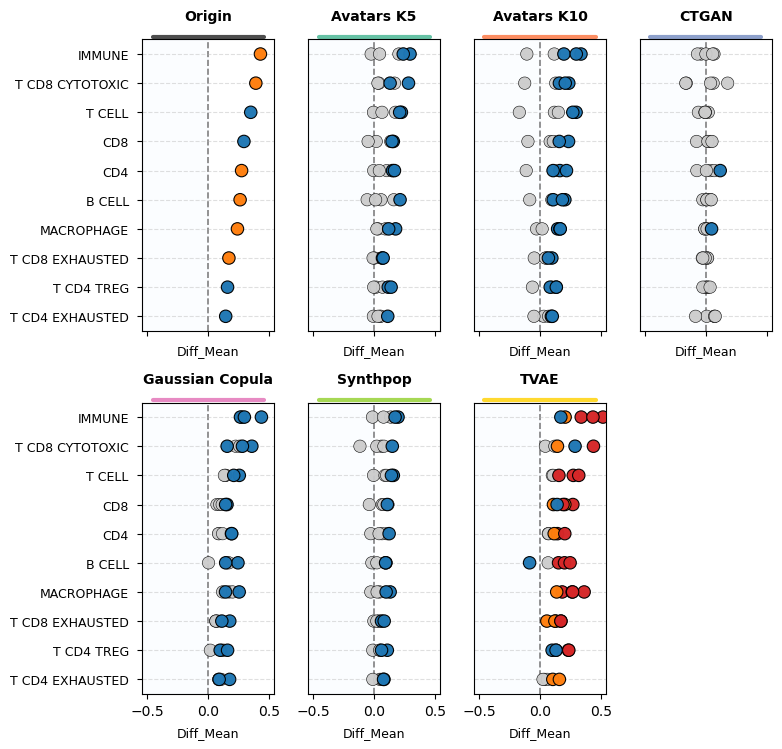

In [12]:
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

ref_pathway_list = results_dict['Origin'].sort_values(by="Q_values")['Cell Type'].values[0:14].tolist()
fig, df_used = plot_pathway(
    ssGSEA_comparison=results_dict,
    ref_pathway_list=ref_pathway_list,
    highlight_pathways=None,
    origin_name="Origin",
    term_col="Cell Type",
    pval_col="Q_values",
    diff_col="Diff_Mean",
    figsize=(9, 8),
    dataset_colors=DATASET_COLORS,
    bubble_size = 80,
    dataset_strip_lw=3.0,
    dataset_strip_y=1.01,
    dataset_strip_pad=0.0,
    show=True,
    save_path=None,
    order_by = "diff",  # "pvalue" (default) or "diff"
    order_ascending = False,
    ncols = 4,
    nrows = 2,
)

# If you want to save the figure:
os.makedirs('DA_Jerby',exist_ok = True)
fig.savefig('DA_Jerby/BubblePlot_Melanoma.pdf', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()